# Offline FFT for TrustMyBike project
We found a dataset of accelerometer and gyroscope data collected from a biker so we decided to use this dataset to run a FFT to determine a ideal sampling frequency

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Root folder
ROOT_DIR = "Bike&Safe_Dataset/Bike&Safe_Dataset"

# Sensors to analyze
SENSORS = ["accelerometer", "gyroscope"]

# Column names (no headers in CSV)
ACC_COLUMNS = ["timestamp", "lap", "x_axis", "y_axis", "z_axis", "magnitude", "null"]
GYR_COLUMNS = ["timestamp", "lap", "x_axis", "y_axis", "z_axis", "null"]

In [14]:
def load_sensor_csv(filepath, route, lap, sensor):
    COLUMNS = ACC_COLUMNS if "acc" in filepath else GYR_COLUMNS
    df = pd.read_csv(filepath, sep=";", header=None)
    df.columns = COLUMNS
    
    # Add metadata
    df["route"] = route
    df["lap_name"] = lap
    df["sensor"] = sensor
    
    return df

In [15]:
def load_all_data(root_dir):
    all_data = []

    for route_name in os.listdir(root_dir):
        route_path = os.path.join(root_dir, route_name)

        if not os.path.isdir(route_path):
            continue

        # Skip non-route folders
        if "route" not in route_name.lower():
            continue

        for lap_name in os.listdir(route_path):
            lap_path = os.path.join(route_path, lap_name)

            if not os.path.isdir(lap_path):
                continue

            for file in os.listdir(lap_path):
                if not file.endswith(".csv"):
                    continue

                for sensor in SENSORS:
                    if sensor in file.lower():
                        filepath = os.path.join(lap_path, file)

                        try:
                            df = load_sensor_csv(filepath, route_name, lap_name, sensor)
                            all_data.append(df)
                        except Exception as e:
                            print(f"Error loading {filepath}: {e}")

    return pd.concat(all_data, ignore_index=True)

In [16]:
data = load_all_data(ROOT_DIR)

print(data.head())
print(data["sensor"].value_counts())

Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/Third lap/BS_Route2_accelerometer_3.csv: Length mismatch: Expected axis has 1 elements, new values have 7 elements
Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/Third lap/BS_Route2_gyroscope_3.csv: Length mismatch: Expected axis has 1 elements, new values have 6 elements
Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/Second lap/BS_Route2_gyroscope_2.csv: Length mismatch: Expected axis has 1 elements, new values have 6 elements
Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/Second lap/BS_Route2_accelerometer_2.csv: Length mismatch: Expected axis has 1 elements, new values have 7 elements
Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/First lap/BS_Route2_accelerometer_1.csv: Length mismatch: Expected axis has 1 elements, new values have 7 elements
Error loading Bike&Safe_Dataset/Bike&Safe_Dataset/Second route/First lap/BS_Route2_gyroscope_1.csv: Length mismatch:

In [17]:
def compute_fft(signal, sampling_rate):
    N = len(signal)
    
    yf = fft(signal)
    xf = fftfreq(N, 1 / sampling_rate)
    
    return xf[:N // 2], np.abs(yf[:N // 2])

In [18]:
def compute_fft(signal, sampling_rate):
    N = len(signal)
    
    yf = fft(signal)
    xf = fftfreq(N, 1 / sampling_rate)
    
    return xf[:N // 2], np.abs(yf[:N // 2])

In [19]:
def analyze_fft(df, axis="x_axis"):
    # Estimate sampling rate
    time_diff = np.diff(df["timestamp"])
    #sampling_rate = 1 / (np.mean(time_diff) / 1000)  # Hz
    sampling_rate = 50 #from the dataset
    signal = df[axis].values

    freqs, magnitude = compute_fft(signal, sampling_rate)

    return freqs, magnitude

In [20]:
def plot_fft_example(data, route, lap, sensor, axis="x_axis"):
    subset = data[
        (data["route"] == route) &
        (data["lap_name"] == lap) &
        (data["sensor"] == sensor)
    ]

    freqs, mag = analyze_fft(subset, axis)

    plt.figure()
    plt.plot(freqs, mag)
    plt.title(f"{sensor} FFT - {route} - {lap} - {axis}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

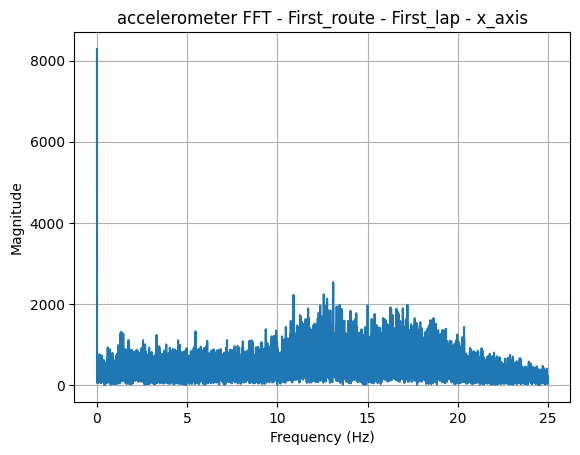

In [21]:
plot_fft_example(
    data,
    route="First_route",
    lap="First_lap",
    sensor="accelerometer",
    axis="x_axis"
)

In [22]:
def plot_fft_all_axes_overlay(data, route, sensor):
    axes = ["x_axis", "y_axis", "z_axis"]

    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    route_data = data[
        (data["route"] == route) &
        (data["sensor"] == sensor)
    ]

    for lap, group in route_data.groupby("lap_name"):
        for i, axis in enumerate(axes):
            signal = group[axis].values 
            sampling_rate = 50
            freqs, mag = compute_fft(signal, sampling_rate)

            axs[i].plot(freqs, mag, alpha=0.3, label=lap if i == 0 else "")

    for i, axis in enumerate(axes):
        axs[i].set_title(axis)
        axs[i].set_ylabel("Magnitude")
        axs[i].grid()

    axs[-1].set_xlabel("Frequency (Hz)")
    plt.xlim(0, 25)

    axs[0].legend()
    plt.suptitle(f"{sensor} FFT - {route} (All Laps)")
    plt.tight_layout()
    plt.show()

In [23]:
print(data[["route", "sensor"]].drop_duplicates())

              route         sensor
0       First_route  accelerometer
24858   First_route      gyroscope
147793  Third route  accelerometer
182233  Third route      gyroscope


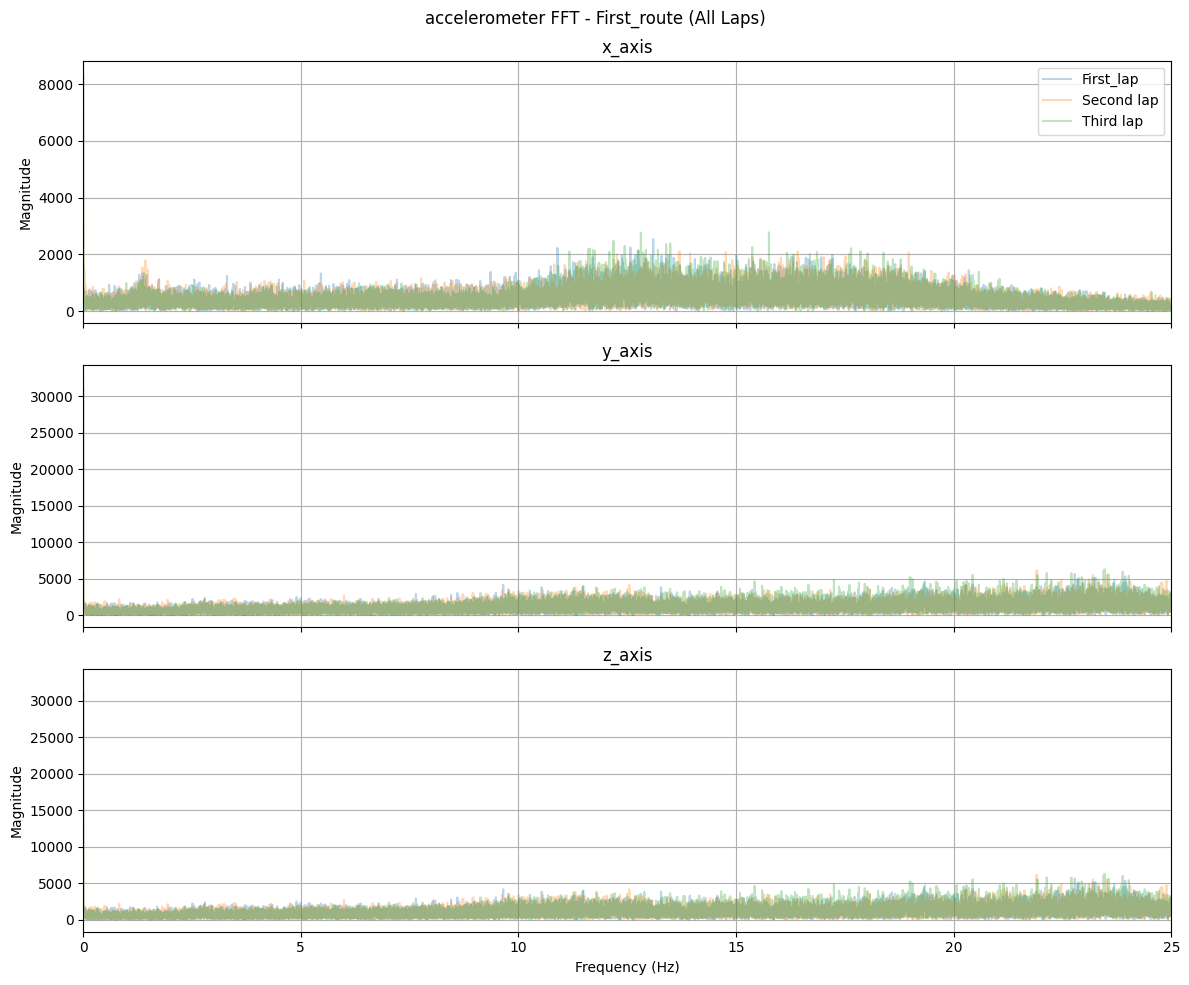

In [24]:
plot_fft_all_axes_overlay(
    data,
    route="First_route",
    sensor="accelerometer"
)

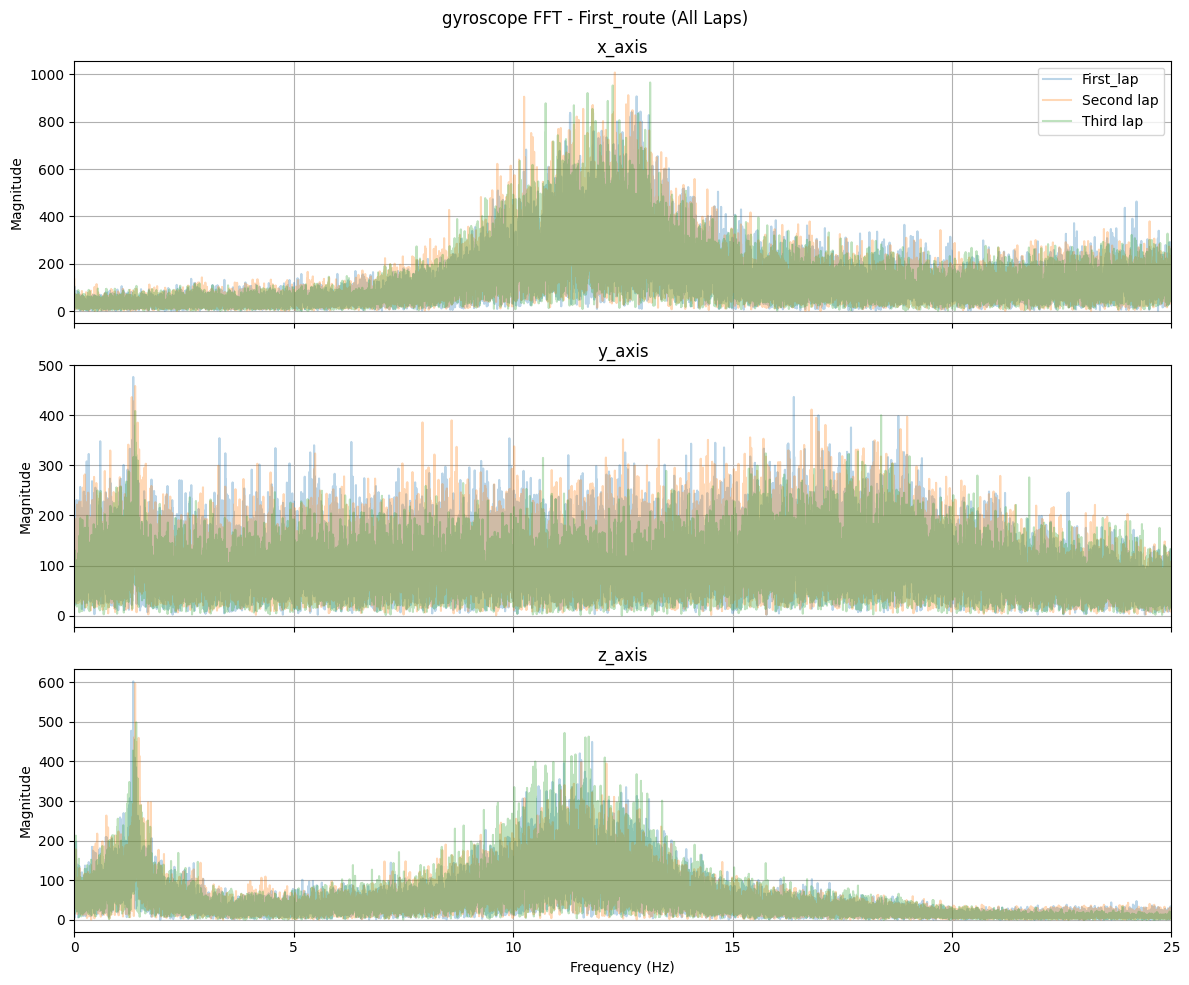

In [25]:
plot_fft_all_axes_overlay(
    data,
    route="First_route",
    sensor="gyroscope"
)

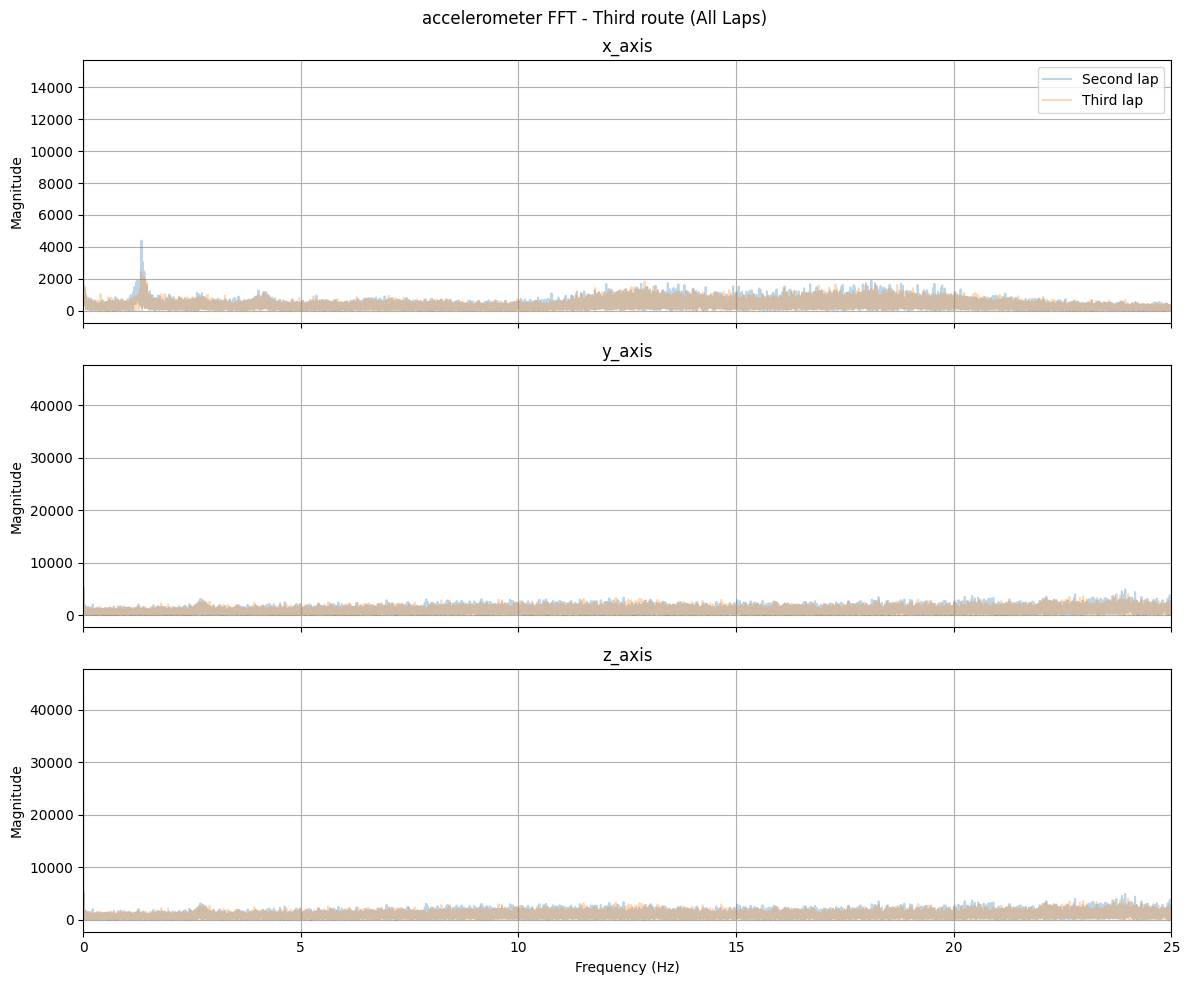

In [26]:
plot_fft_all_axes_overlay(
    data,
    route="Third route",
    sensor="accelerometer"
)

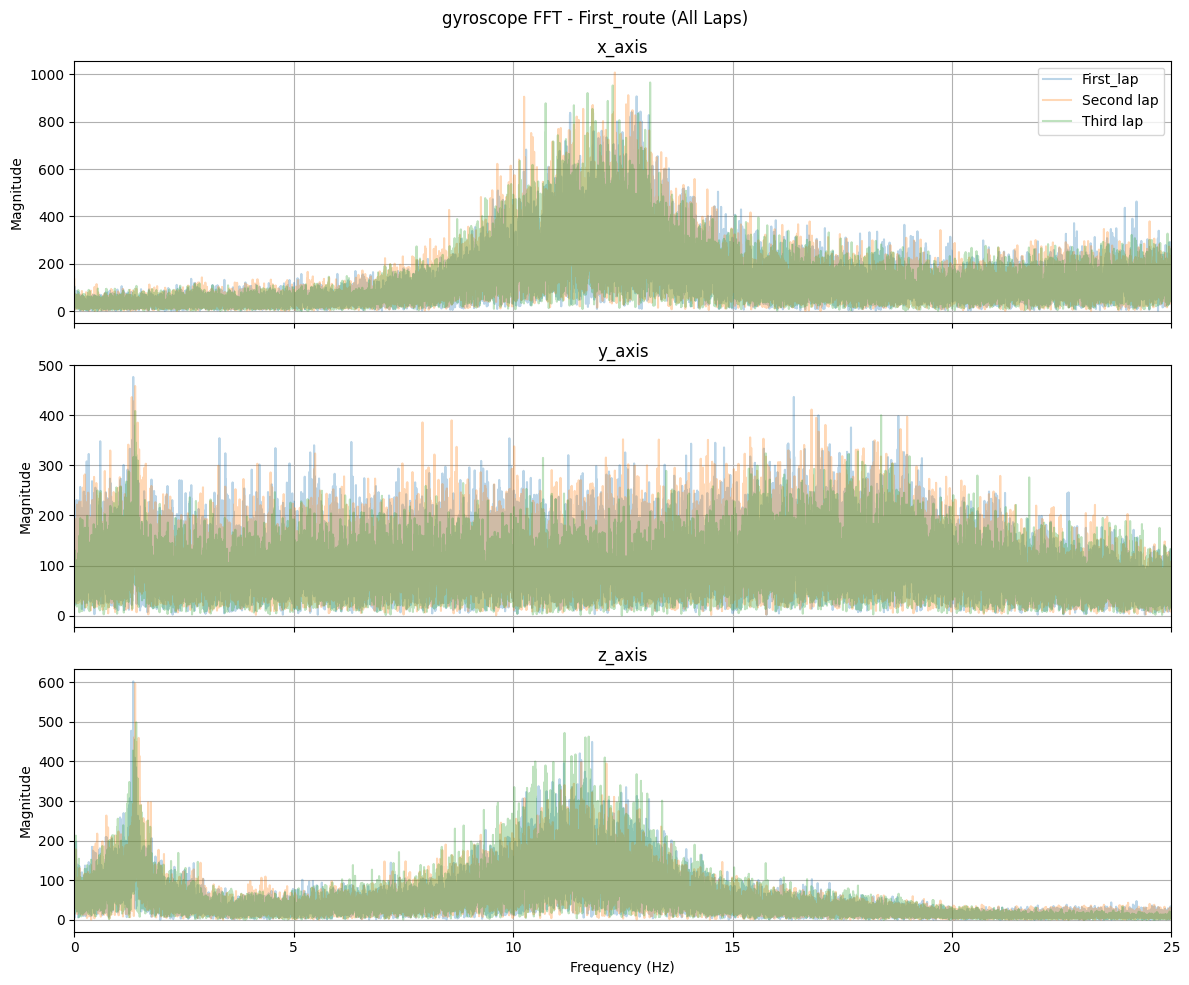

In [27]:
plot_fft_all_axes_overlay(
    data,
    route="First_route",
    sensor="gyroscope"
)

# Data from our own experience
This is just a try to see if the data are collected correctly, calibration is not the best so we have some problem

          0     1      2     3     4    5
0      0.04 -0.02   9.86 -0.00 -0.00 -0.0
1      0.10  0.02   9.63  0.00 -0.01 -0.0
2     -0.08  0.00  10.07 -0.01  0.03 -0.0
3     -0.07 -0.02  10.17 -0.00  0.00 -0.0
4      0.08  0.03   9.46  0.01 -0.03  0.0
...     ...   ...    ...   ...   ...  ...
18197  0.02 -0.03   9.83  0.00  0.00  0.0
18198 -0.02  0.01   9.85 -0.00  0.00 -0.0
18199 -0.01  0.01   9.79  0.00  0.00 -0.0
18200  0.02 -0.02   9.76 -0.00 -0.00 -0.0
18201 -0.01  0.02   9.85 -0.00 -0.00 -0.0

[18202 rows x 6 columns]


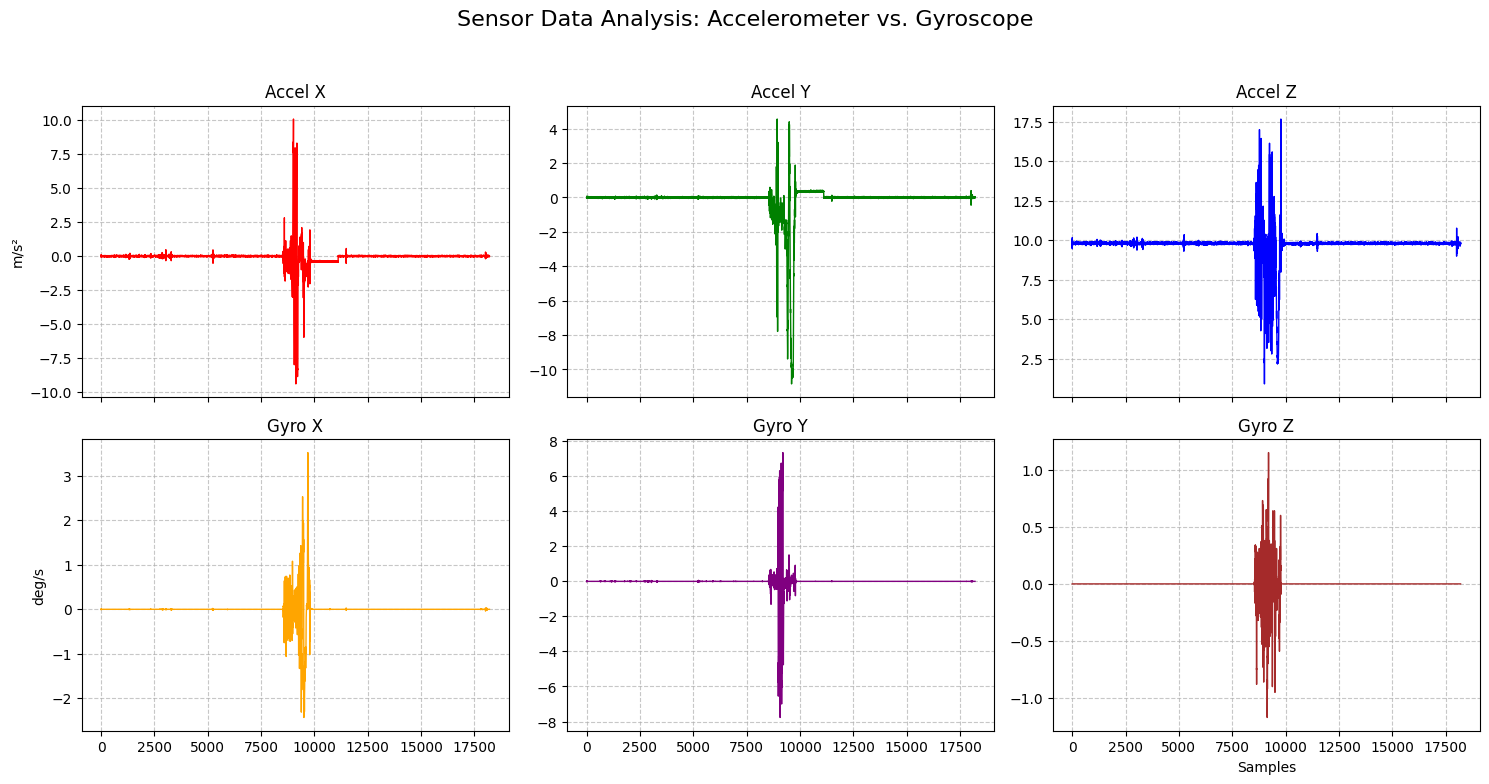

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Load the data
# Replace 'your_data.csv' with your actual filename
raw_data = open("OwnDataset/data.csv").read()

# 2. Replace the semicolon with a newline character
cleaned_data = raw_data.replace(';', '\n')

# 3. Use io.StringIO to make the string act like a file for pandas
df = pd.read_csv(io.StringIO(cleaned_data), header=None)

print(df)
# 2. Setup the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), sharex=True)
fig.suptitle('Sensor Data Analysis: Accelerometer vs. Gyroscope', fontsize=16)

# Define column names and colors for styling
cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
colors = ['r', 'g', 'b', 'orange', 'purple', 'brown']
titles = ['Accel X', 'Accel Y', 'Accel Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
df.columns = cols

# 3. Loop through columns to plot
for i, col in enumerate(cols):
    row = i // 3  # First 3 go in row 0, next 3 in row 1
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    ax.plot(df[col], color=colors[i], linewidth=1)
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Optional: Label Y-axis for the first column of each row
    if col_idx == 0:
        ax.set_ylabel('m/s²' if row == 0 else 'deg/s')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.xlabel('Samples')
plt.show()

In [29]:
df.head()

,ax,ay,az,gx,gy,gz
0,0.04,-0.02,9.86,-0.00,-0.00,-0.0
1,0.10,0.02,9.63,0.00,-0.01,-0.0
2,-0.08,0.00,10.07,-0.01,0.03,-0.0
3,-0.07,-0.02,10.17,-0.00,0.00,-0.0
4,0.08,0.03,9.46,0.01,-0.03,0.0


In [30]:

# 1. Setup parameters
fs = 100  # Sampling frequency (Hz)
T = 1/fs  # Sampling period
N = len(df)  # Number of samples

# 2. Prepare a dictionary to store results
fft_results = {}

# Calculate the frequency axis (same for all columns)
# We take only the positive half of the spectrum
xf = fftfreq(N, T)[:N//2]

for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
    # Compute the FFT
    yf = fft(df[col].values)
    
    # Take the magnitude and normalize, keeping only the positive frequencies
    # We multiply by 2.0 to account for the energy in the negative frequencies
    fft_magnitude = 2.0/N * np.abs(yf[0:N//2])
    
    fft_results[col] = fft_magnitude

# 3. Convert results to a new DataFrame for easy analysis
df_fft = pd.DataFrame(fft_results, index=xf)
df_fft.index.name = 'Frequency_Hz'

<Figure size 1200x600 with 0 Axes>

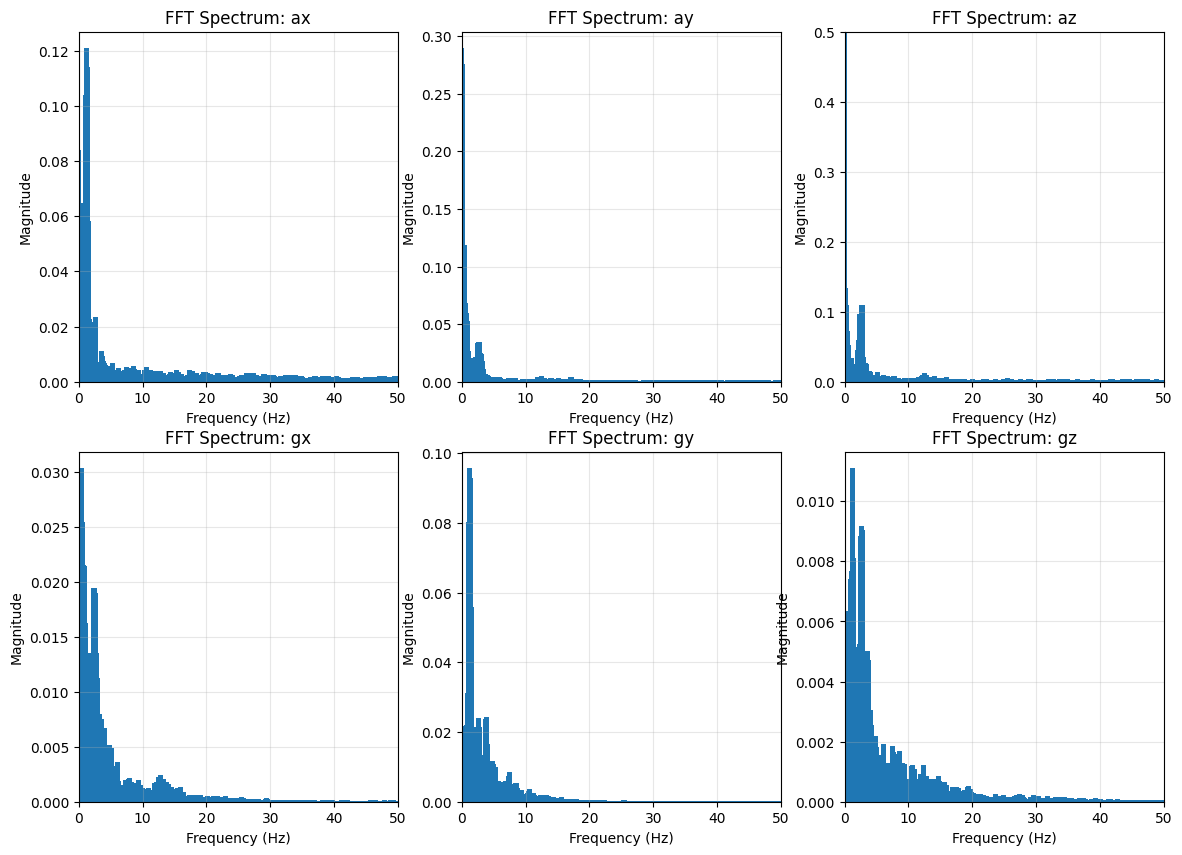

In [45]:
plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))
axes = axes.flatten()  # Flatten to iterate easily
i = 0;
for col in df_fft.columns:
    axes[i].bar(df_fft.index, df_fft[col], label=col)
    axes[i].set_title(f'FFT Spectrum: {col}')
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Magnitude')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, 50)  # Limit to Nyquist frequency
    if col == 'az':
        axes[i].set_ylim(0, 0.5) # manually set because I was not be able to see anything
    i += 1

plt.grid(True)
plt.show()